In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
%matplotlib inline

In [51]:
df = pd.read_csv('../data/pro_data/ml_project1_data.csv')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


### Grupo 1 — Datos en bruto (USD)

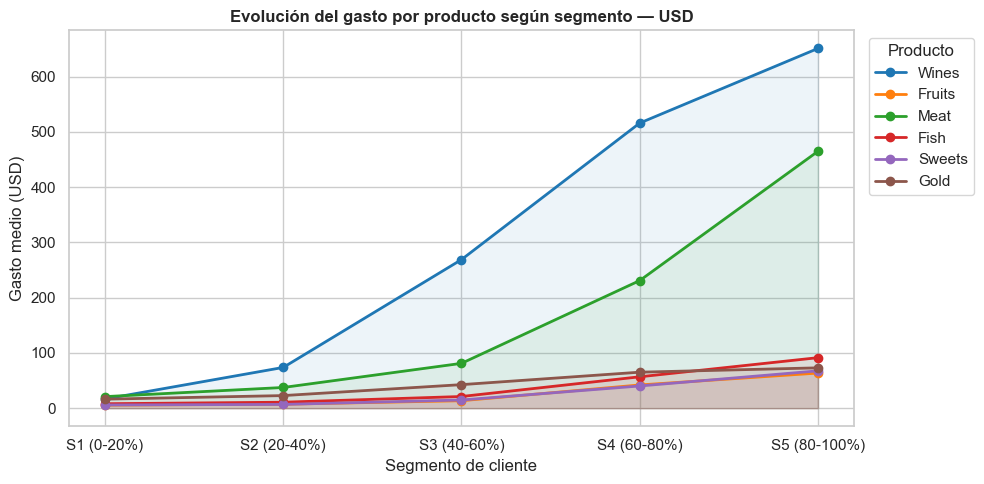

In [52]:
seg_palette = ['#d9534f', '#f0ad4e', '#5bc0de', '#5cb85c', '#0275d8']
prod_palette = sns.color_palette('tab10', n_colors=6)




# --- Líneas de evolución por producto ---
fig, ax = plt.subplots(figsize=(10, 5))
for col, color in zip(mean_raw.columns, prod_palette):
    ax.plot(mean_raw.index, mean_raw[col], marker='o', label=col, color=color, linewidth=2)
    ax.fill_between(mean_raw.index, mean_raw[col], alpha=0.08, color=color)
ax.set_title('Evolución del gasto por producto según segmento — USD', fontweight='bold')
ax.set_xlabel('Segmento de cliente')
ax.set_ylabel('Gasto medio (USD)')
ax.legend(title='Producto', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

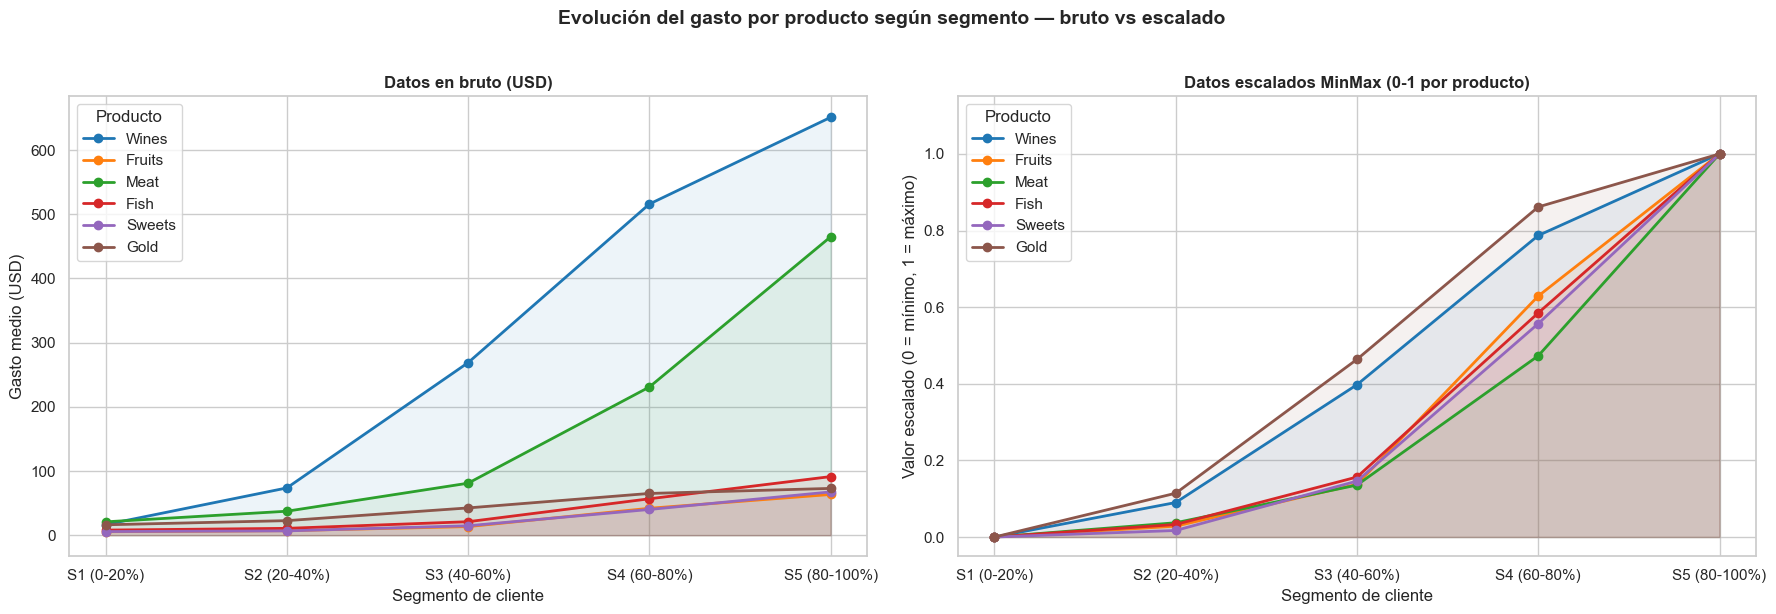

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

# --- Izquierda: datos en bruto ---
for col, color in zip(mean_raw.columns, prod_palette):
    axes[0].plot(mean_raw.index, mean_raw[col], marker='o', label=col, color=color, linewidth=2)
    axes[0].fill_between(mean_raw.index, mean_raw[col], alpha=0.08, color=color)
axes[0].set_title('Datos en bruto (USD)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Segmento de cliente')
axes[0].set_ylabel('Gasto medio (USD)')
axes[0].legend(title='Producto')

# --- Derecha: datos escalados MinMax ---
for col, color in zip(mean_scaled.columns, prod_palette):
    axes[1].plot(mean_scaled.index, mean_scaled[col], marker='o', label=col, color=color, linewidth=2)
    axes[1].fill_between(mean_scaled.index, mean_scaled[col], alpha=0.08, color=color)
axes[1].set_ylim(-0.05, 1.15)
axes[1].set_title('Datos escalados MinMax (0-1 por producto)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Segmento de cliente')
axes[1].set_ylabel('Valor escalado (0 = mínimo, 1 = máximo)')
axes[1].legend(title='Producto')

plt.suptitle('Evolución del gasto por producto según segmento — bruto vs escalado', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

En este grafico he escalado los datos porque lo que queria poder comparar la variabilidad a medida que aumenta el income en una sola escala para poder comparar las diferentes lineas.

Se pueden apreciar dos grupos (wine-gold) y otro grupo con el resto, que reaccionan de manera similar a los aumentos en el income de los consumidores.

Como conclusión observamos que independientemente del grupo de productos, las ventas tienden a aumentar a medida que aumenta el income del consumidor.


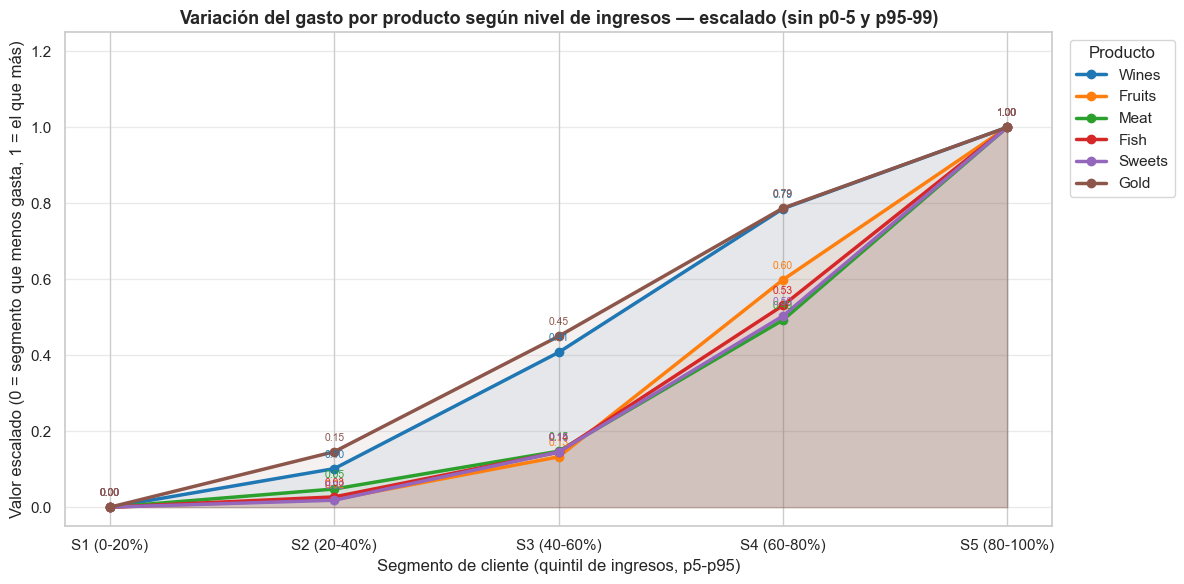

In [54]:
p5  = df_plot['Income'].quantile(0.05)
p95 = df_plot['Income'].quantile(0.95)
df_trim = df_plot[(df_plot['Income'] >= p5) & (df_plot['Income'] <= p95)].copy()

df_trim['Segmento'] = pd.qcut(
    df_trim['Income'], q=5,
    labels=['S1 (0-20%)', 'S2 (20-40%)', 'S3 (40-60%)', 'S4 (60-80%)', 'S5 (80-100%)']
)

mean_raw_trim = df_trim.groupby('Segmento', observed=True)[mnt_cols].mean()
mean_raw_trim.columns = mnt_labels

mean_scaled_trim = pd.DataFrame(
    MinMaxScaler().fit_transform(mean_raw_trim),
    index=mean_raw_trim.index,
    columns=mean_raw_trim.columns
)

fig, ax = plt.subplots(figsize=(12, 6))

for col, color in zip(mean_scaled_trim.columns, prod_palette):
    ax.plot(mean_scaled_trim.index, mean_scaled_trim[col], marker='o', label=col, color=color, linewidth=2.5)
    ax.fill_between(mean_scaled_trim.index, mean_scaled_trim[col], alpha=0.08, color=color)
    for x, y in enumerate(mean_scaled_trim[col]):
        ax.annotate(f'{y:.2f}', (x, y), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=7.5, color=color)

ax.set_ylim(-0.05, 1.25)
ax.set_title('Variación del gasto por producto según nivel de ingresos — escalado (sin p0-5 y p95-99)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Segmento de cliente (quintil de ingresos, p5-p95)')
ax.set_ylabel('Valor escalado (0 = segmento que menos gasta, 1 = el que más)')
ax.legend(title='Producto', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

Aqui queria excluir posibles outliers para ver que estos no me hubieran podido distorsionar los datos y parece que todo esta correcto. Doy la conclusión anterior como valida.